<a href="https://colab.research.google.com/github/Emdejeee/2025_Pengolahan_citra_TI2C/blob/main/TUGAS_AKHIR_Pengolahan%20Citra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

_Exercise: Try using a denoising autoencoder to pretrain an image classifier. You can use MNIST (the simplest option), or a more complex image dataset such as [CIFAR10](https://homl.info/122) if you want a bigger challenge. Regardless of the dataset you're using, follow these steps:_
* Split the dataset into a training set and a test set. Train a deep denoising autoencoder on the full training set.
* Check that the images are fairly well reconstructed. Visualize the images that most activate each neuron in the coding layer.
* Build a classification DNN, reusing the lower layers of the autoencoder. Train it using only 500 images from the training set. Does it perform better with or without pretraining?

## 1. Setup & Load CIFAR-10

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.layers import Dense, Flatten, Reshape, GlobalAveragePooling2D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 147s 1us/step


## 2. Add Gaussian Noise

In [ ]:
noise_factor = 0.1
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)


## 3. Denoising Autoencoder

In [ ]:
input_img = Input(shape=(32, 32, 3))

# Encoder
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)  # (8, 8, 64)

# Decoder
x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
decoded = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 8, 8, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_2 (UpSampling2D)       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 16, 16, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_3 (UpSampling2D)       │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 32, 32, 3)           │             867 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 75,651 (295.51 KB)

 Trainable params: 75,651 (295.51 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Train the Autoencoder

In [ ]:
autoencoder.fit(
    x_train_noisy, x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 58s 130ms/step - loss: 0.0196 - val_loss: 0.0065
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 50s 129ms/step - loss: 0.0062 - val_loss: 0.0054
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 50s 128ms/step - loss: 0.0054 - val_loss: 0.0049
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 50s 128ms/step - loss: 0.0048 - val_loss: 0.0045
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 82s 128ms/step - loss: 0.0045 - val_loss: 0.0046
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 49s 126ms/step - loss: 0.0043 - val_loss: 0.0042
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 51s 131ms/step - loss: 0.0041 - val_loss: 0.0039
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 84s 135ms/step - loss: 0.0039 - val_loss: 0.0037
Epoch 9/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 80s 130ms/step - loss: 0.0038 - val_loss: 0.0036
Epoch 10/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 81s 128ms/step - loss: 0.0037 - val_loss: 0.0035


## 5. Visualize Reconstructed vs Noisy Images

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step


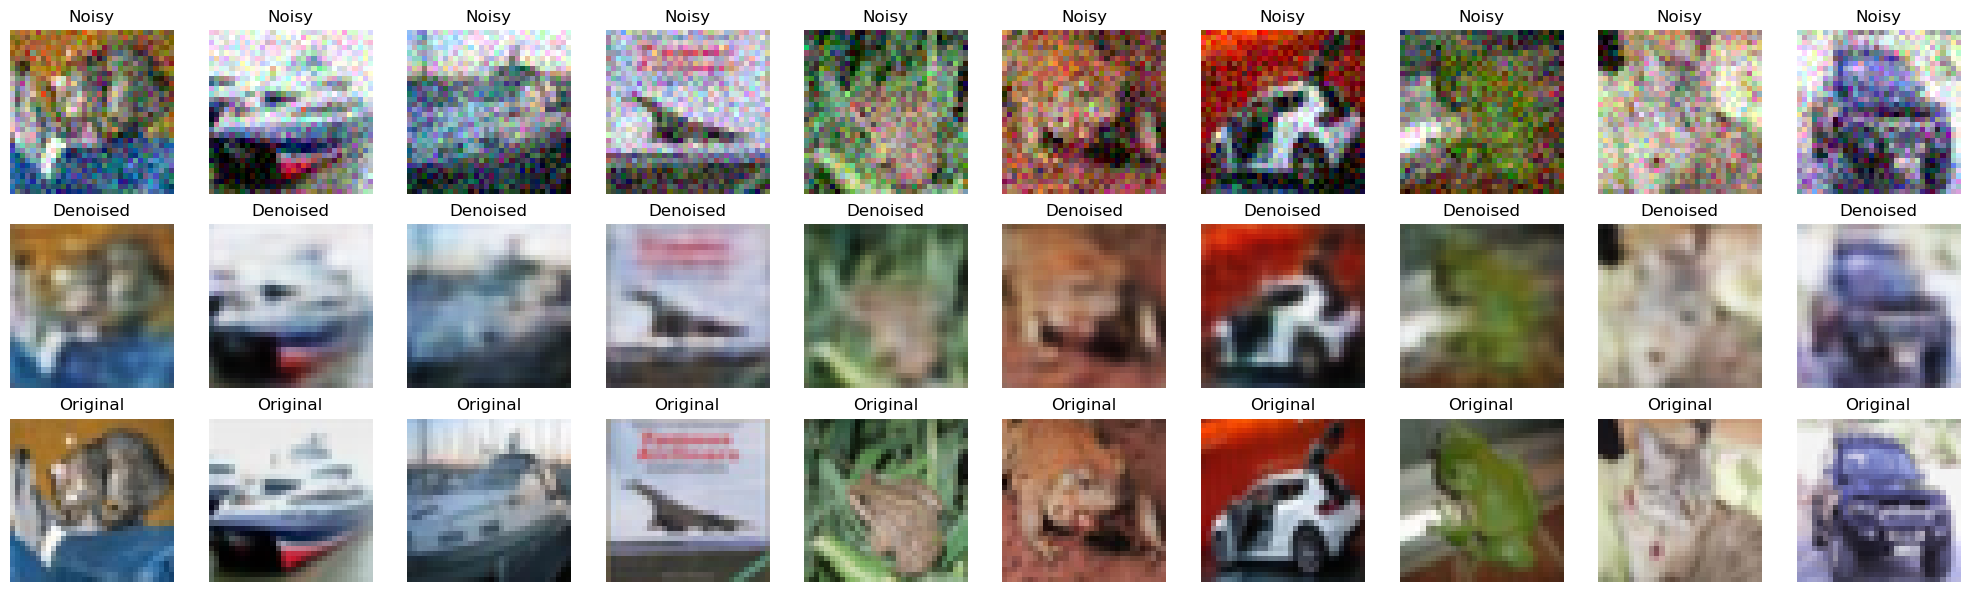

In [ ]:
decoded_imgs = autoencoder.predict(x_test_noisy)

n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test_noisy[i])
    plt.title("Noisy")
    plt.axis("off")

    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(decoded_imgs[i])
    plt.title("Denoised")
    plt.axis("off")

    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(x_test[i])
    plt.title("Original")
    plt.axis("off")
plt.tight_layout()
plt.show()


## 6. Build Classifier With Pretraining

In [ ]:
encoder = Model(input_img, encoded)

encoded_input = encoder.input
x = encoder.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(10, activation='softmax')(x)

classifier_pretrained = Model(encoded_input, output)
classifier_pretrained.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

x_small = x_train[:500]
y_small = y_train_cat[:500]

classifier_pretrained.fit(x_small, y_small, epochs=20, batch_size=64, validation_data=(x_test, y_test_cat))


Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 463ms/step - accuracy: 0.1176 - loss: 2.3042 - val_accuracy: 0.1008 - val_loss: 2.2919
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 348ms/step - accuracy: 0.1273 - loss: 2.2656 - val_accuracy: 0.1044 - val_loss: 2.2759
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 418ms/step - accuracy: 0.1254 - loss: 2.2569 - val_accuracy: 0.1450 - val_loss: 2.2453
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 425ms/step - accuracy: 0.1765 - loss: 2.2176 - val_accuracy: 0.1502 - val_loss: 2.2127
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 794ms/step - accuracy: 0.1813 - loss: 2.1714 - val_accuracy: 0.2135 - val_loss: 2.1603
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 374ms/step - accuracy: 0.2159 - loss: 2.1285 - val_accuracy: 0.2101 - val_loss: 2.1268
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 788ms/step - accuracy: 0.2520 - loss: 2.0661 - val_accuracy: 0.2132 - val_loss: 2.1284
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 796ms/step - accuracy: 0.2132 - loss: 2.0729 - val_accuracy: 0.2216 - val_loss

## 7. Classifier Without Pretraining

In [ ]:
classifier_plain = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2), padding='same'),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2), padding='same'),
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

classifier_plain.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
classifier_plain.fit(x_small, y_small, epochs=20, batch_size=64, validation_data=(x_test, y_test_cat))


Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 511ms/step - accuracy: 0.1068 - loss: 2.3055 - val_accuracy: 0.1000 - val_loss: 2.2999
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 404ms/step - accuracy: 0.1059 - loss: 2.2875 - val_accuracy: 0.1022 - val_loss: 2.2971
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 469ms/step - accuracy: 0.1289 - loss: 2.2721 - val_accuracy: 0.1000 - val_loss: 2.2908
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 799ms/step - accuracy: 0.1348 - loss: 2.2663 - val_accuracy: 0.1387 - val_loss: 2.2709
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 787ms/step - accuracy: 0.1529 - loss: 2.2466 - val_accuracy: 0.1643 - val_loss: 2.2404
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 498ms/step - accuracy: 0.1857 - loss: 2.1911 - val_accuracy: 0.1715 - val_loss: 2.2037
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 798ms/step - accuracy: 0.2124 - loss: 2.1489 - val_accuracy: 0.1961 - val_loss: 2.1496
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 797ms/step - accuracy: 0.2104 - loss: 2.1022 - val_accuracy: 0.1926 - val_los

## 8. Compare Accuracy

In [ ]:
acc_pretrained = classifier_pretrained.evaluate(x_test, y_test_cat, verbose=0)[1]
acc_plain = classifier_plain.evaluate(x_test, y_test_cat, verbose=0)[1]

print(f"Test accuracy WITH pretraining: {acc_pretrained:.4f}")
print(f"Test accuracy WITHOUT pretraining: {acc_plain:.4f}")


Test accuracy WITH pretraining: 0.2538
Test accuracy WITHOUT pretraining: 0.2640
